# Visualisations

In [15]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

## 01 Visualisation of the Construction Plan

In [20]:
from helper.position.parse_acc import parse_acc
from helper.position.remove_gravity import remove_gravity_ema


def get_ls_df(participant_id, length, folder, step):
    """Load and preprocess trajectory DataFrames for one participant/construct."""
    result = []
    for i in range(length):
        path = f"{folder}/{participant_id}/{i}.csv"
        df = pd.read_csv(path)
        df[["t_acc", "ax", "ay", "az"]] = df["ax_sensor"].apply(parse_acc)
        df[["t_gx", "gx", "gy", "gz"]]  = df["gx_sensor"].apply(parse_acc)
        df2 = remove_gravity_ema(df, alpha=0.95)
        df2['x_pos'] = df2['x_new']
        df2['y_pos'] = df2['y_new']

        final_df = df2[['ax_lin', 'ay_lin', 'az_lin', 'a_lin_mag',
                         'gx', 'gy', 'gz', 'x_pos', 'y_pos',
                         'android_image_filename']].copy()
        final_df["target_x_raw"]  = final_df["x_pos"].shift(-step)
        final_df["target_y_raw"]  = final_df["y_pos"].shift(-step)
        final_df["next_image"]    = final_df["android_image_filename"].shift(-step)
        final_df["current_image"] = final_df["android_image_filename"]
        result.append(final_df)
    return result


# Folder paths
FOLDER_TRAIN = "Dataset/merged_data"
FOLDER_TEST  = "Dataset/eval_data"

# Participant IDs per construct
ID_LONG    = 0
ID_FORWARD = 1
ID_BACK    = 2

# Number of trials per construct
TRAIN_LONG    = 6
TRAIN_FORWARD = 8
TRAIN_BACK    = 9
LEN_TEST      = 1

# Prediction horizon (frames to look ahead for target position)
STEP = 1

ls_train_long    = get_ls_df(ID_LONG,    TRAIN_LONG,    FOLDER_TRAIN, STEP)
ls_train_forward = get_ls_df(ID_FORWARD, TRAIN_FORWARD, FOLDER_TRAIN, STEP)
ls_train_back    = get_ls_df(ID_BACK,    TRAIN_BACK,    FOLDER_TRAIN, STEP)

ls_test_long    = get_ls_df(ID_LONG,    LEN_TEST, FOLDER_TEST, STEP)
ls_test_forward = get_ls_df(ID_FORWARD, LEN_TEST, FOLDER_TEST, STEP)
ls_test_back    = get_ls_df(ID_BACK,    LEN_TEST, FOLDER_TEST, STEP)

In [21]:
def transform_points(x, y, angle_degrees, shift_x=0, shift_y=0, center=(0, 0)):
    """Rotate points around `center` then apply an optional translation. Returns coordinates in meters (cm / 100)."""
    angle_rad = np.radians(angle_degrees)
    ox, oy = center

    # Translate to rotation center
    x_c = x - ox
    y_c = y - oy

    # Apply rotation matrix
    x_rot = x_c * np.cos(angle_rad) - y_c * np.sin(angle_rad)
    y_rot = x_c * np.sin(angle_rad) + y_c * np.cos(angle_rad)

    # Translate back, apply global offset, and convert cm → m
    return ((x_rot + ox) + shift_x) / 100, ((y_rot + oy) + shift_y) / 100


def set_rotation(df, angle=2.8):
    """Rotate x_pos/y_pos by `angle` degrees in-place and convert cm → m."""
    if angle == 0:
        df['x_pos'] = df['x_pos'] / 100
        df['y_pos'] = df['y_pos'] / 100
        return df

    df['x_pos'], df['y_pos'] = transform_points(
        df['x_pos'], df['y_pos'],
        angle_degrees=angle,
        center=(0, 0),
    )
    return df


# Normalize forward and back trajectories (cm → m, no rotation needed)
ls_train_forward_new = [
    df.assign(x_pos=df['x_pos'] / 100, y_pos=df['y_pos'] / 100)
    for df in ls_train_forward
]
ls_train_back_new = [
    df.assign(x_pos=df['x_pos'] / 100, y_pos=df['y_pos'] / 100)
    for df in ls_train_back
]

# Long trajectories require per-trial rotation correction
long_angles = [-1, 2.8, -0.8, -0.8, -0.8, 1.0]
ls_long_train_new = [
    set_rotation(df.copy(), angle=a)
    for df, a in zip(ls_train_long, long_angles)
]

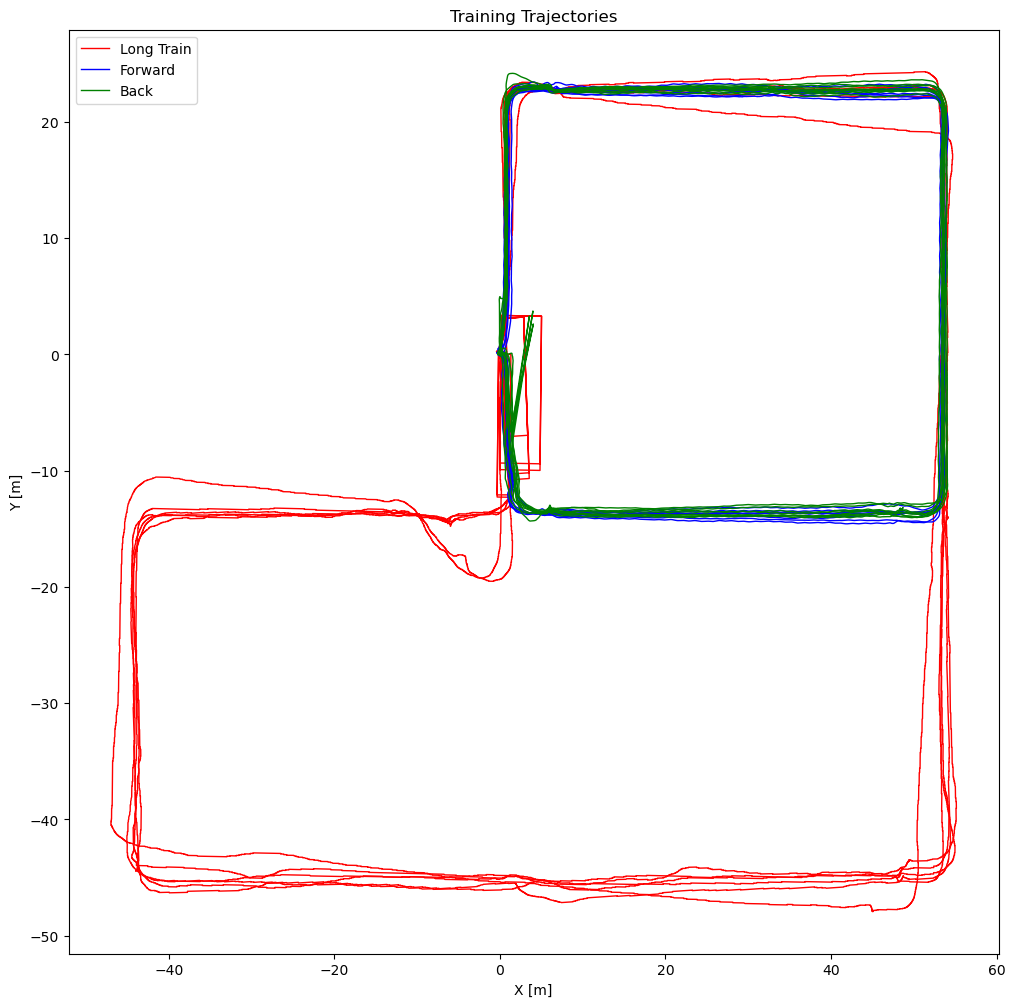

In [22]:
color_ls = ['red', 'blue', 'green']
label_ls  = ['Long Train', 'Forward', 'Back']

fig, ax = plt.subplots(figsize=(12, 12))

for ls, color, label in zip(
        [ls_long_train_new, ls_train_forward_new, ls_train_back_new],
        color_ls, label_ls):
    for i, df in enumerate(ls):
        ax.plot(df['x_pos'], df['y_pos'],
                color=color, linewidth=1, zorder=1,
                label=label if i == 0 else None)

ax.legend()
ax.set_title('Training Trajectories')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
plt.show()

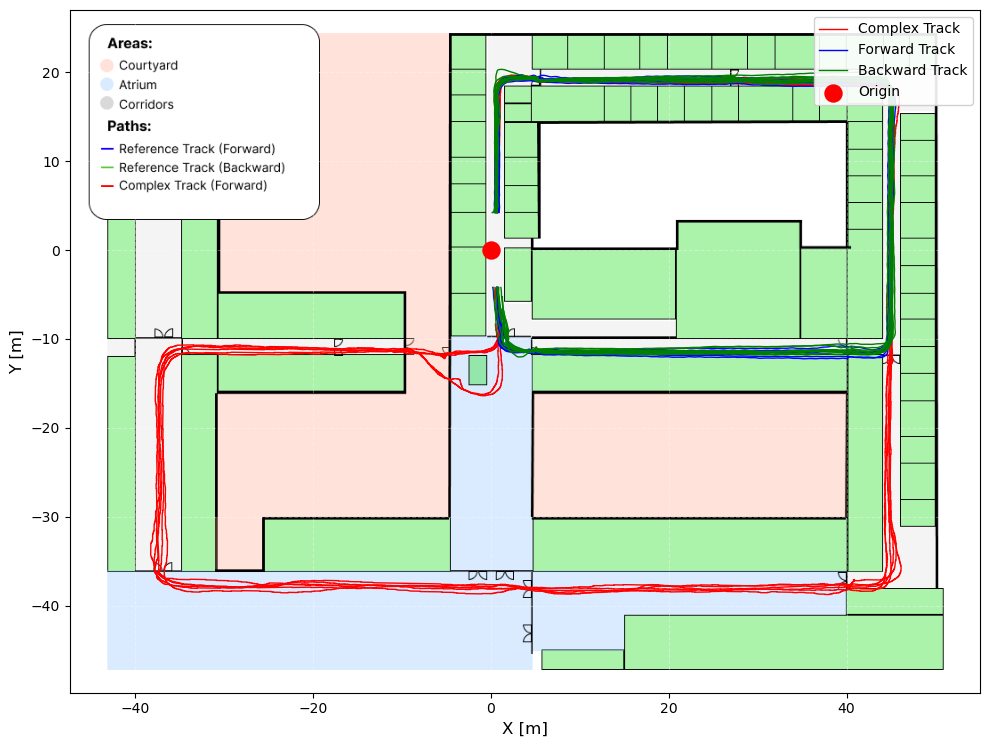

In [19]:
SCALE_FACTOR   = 0.1   # raw pixel units → meters (1 dm = 0.1 m)
PIXEL_TO_WORLD = 8.4 * SCALE_FACTOR  # combined scale: trajectory coords → meters

# Load and prepare the floor plan background image
img = cv2.imread('img/visualisation_construction_plan.png')
if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.flip(img, 0)  # flip vertically to match origin='lower'
    height, width = img.shape[:2]
else:
    height, width = 500, 600
    img = np.zeros((height, width, 3), dtype=np.uint8) + 240  # light-grey fallback

# Pixel offset of the coordinate origin within the floor plan image
origin_px_x = 474
origin_px_y = -270

# Map image pixel corners to world coordinates (meters)
extent = [
    -origin_px_x * SCALE_FACTOR,
    (width  - origin_px_x) * SCALE_FACTOR,
    (-height - origin_px_y) * SCALE_FACTOR,
    -origin_px_y * SCALE_FACTOR,
]

label_ls = ['Complex Track', 'Forward Track', 'Backward Track']

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img, extent=extent, origin='lower', zorder=0)

for ls, color, label in zip(
        [ls_long_train_new, ls_train_forward_new, ls_train_back_new],
        color_ls, label_ls):
    for i, df in enumerate(ls):
        ax.plot(
            df['x_pos'] * PIXEL_TO_WORLD,
            df['y_pos'] * PIXEL_TO_WORLD,
            color=color,
            linewidth=1.0,
            zorder=2,
            label=label if i == 0 else None,
        )

ax.scatter(0, 0, color='red', s=150, marker='o', zorder=3, label='Origin')
ax.set_aspect('equal')
ax.set_xlabel('X [m]', fontsize=12)
ax.set_ylabel('Y [m]', fontsize=12)
ax.grid(True, alpha=0.3, color='white', linestyle='--')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
 
# --- Load ---
df = pd.read_csv("cv_results_full.csv")
 
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFolds / datasets:\n{df[['fold', 'test_dataset']].drop_duplicates().to_string(index=False)}")
print(f"\nDatentypen:\n{df.dtypes}")
print(f"\nErste Zeilen:\n{df.head()}")
 
# --- Quick summary per fold ---
summary = (
    df.groupby(["fold", "test_dataset"])
    .agg(
        n_configs=("radius", "count"),
        acc_mean=("test_accuracy", "mean"),
        acc_max=("test_accuracy", "max"),
        f1w_mean=("test_f1_weighted", "mean"),
        f1w_max=("test_f1_weighted", "max"),
        samples=("test_samples", "first"),
    )
    .reset_index()
)
print(f"\n--- Summary per fold ---\n{summary.to_string(index=False)}")
 
# --- Best config per fold (by test_accuracy) ---
best_per_fold = (
    df.loc[df.groupby("fold")["test_accuracy"].idxmax()]
    [["fold", "test_dataset", "radius", "threshold", "fps_simulated",
      "test_accuracy", "test_f1_weighted", "test_f1_links", "test_f1_gerade", "test_f1_rechts"]]
    .reset_index(drop=True)
)
print(f"\n--- Best config per fold ---\n{best_per_fold.to_string(index=False)}")
 
# --- Overall weighted F1 at best global config (R=450, T=1.0, 30Hz) ---
best = df[(df.radius == 450) & (df.threshold == 1.0) & (df.fps_simulated == 30.0)].copy()
total_n = best["test_samples"].sum()
weighted_acc = (best["test_accuracy"] * best["test_samples"]).sum() / total_n
weighted_f1  = (best["test_f1_weighted"] * best["test_samples"]).sum() / total_n
 
print(f"\n--- Overall @ R=450, T=1.0, 30Hz ---")
print(f"  Total samples : {total_n}")
print(f"  Weighted Acc  : {weighted_acc:.4f}  ({weighted_acc*100:.1f}%)")
print(f"  Weighted F1   : {weighted_f1:.4f}  ({weighted_f1*100:.1f}%)")

Shape: 180 rows × 17 columns

Columns:
['fold', 'test_dataset', 'radius', 'threshold', 'fps_simulated', 'train_accuracy', 'train_f1_weighted', 'train_f1_macro', 'test_accuracy', 'test_f1_weighted', 'test_f1_macro', 'test_f1_links', 'test_f1_gerade', 'test_f1_rechts', 'train_skipped', 'test_skipped', 'test_samples']

Folds / datasets:
 fold test_dataset
    1         Long
    2      Forward
    3         Back

Datentypen:
fold                   int64
test_dataset          object
radius                 int64
threshold            float64
fps_simulated        float64
train_accuracy       float64
train_f1_weighted    float64
train_f1_macro       float64
test_accuracy        float64
test_f1_weighted     float64
test_f1_macro        float64
test_f1_links        float64
test_f1_gerade       float64
test_f1_rechts       float64
train_skipped          int64
test_skipped           int64
test_samples           int64
dtype: object

Erste Zeilen:
   fold test_dataset  radius  threshold  fps_simulate

In [2]:
df.loc[df.groupby("fold")["test_f1_weighted"].idxmax()]


,fold,test_dataset,radius,threshold,fps_simulated,train_accuracy,train_f1_weighted,train_f1_macro,test_accuracy,test_f1_weighted,test_f1_macro,test_f1_links,test_f1_gerade,test_f1_rechts,train_skipped,test_skipped,test_samples
14,1,Long,450,1.0,30.0,0.947368,0.972299,0.649123,0.928571,0.928763,0.873802,0.769231,0.866667,0.985507,0,0,56
108,2,Forward,550,0.5,15.0,0.902174,0.897517,0.843285,0.950000,0.974359,0.324786,0.000000,0.000000,0.974359,0,0,40
126,3,Back,350,0.5,30.0,0.885417,0.887932,0.747170,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0,0,36


In [3]:
df.groupby(["radius", "threshold", "fps_simulated"])["test_f1_weighted"].mean().idxmax()


(450, 1.0, 30.0)

In [4]:
best_global = df[(df.radius == 450) & (df.threshold == 1.0) & (df.fps_simulated == 30.0)][
    ["fold", "test_dataset", "test_accuracy", "test_f1_weighted",
     "test_f1_links", "test_f1_gerade", "test_f1_rechts", "test_samples"]
].reset_index(drop=True)

print(best_global.to_string(index=False))

 fold test_dataset  test_accuracy  test_f1_weighted  test_f1_links  test_f1_gerade  test_f1_rechts  test_samples
    1         Long       0.928571          0.928763       0.769231        0.866667        0.985507            56
    2      Forward       0.900000          0.947368       0.000000        0.000000        0.947368            40
    3         Back       1.000000          1.000000       1.000000        0.000000        0.000000            36
